In [7]:
import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *
from cardpy.Data_Processing.Denoising               import *
from cardpy.Data_Processing.Interpolation           import *
from cardpy.Data_Processing.Segmentation_Matrix_DTI import *
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.Data_Processing.DWI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
from cardpy.GUI_Tools                     import *
from cardpy.Colormaps                     import *
# import cardpy
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from matplotlib import pyplot as plt
import os
import subprocess
import nibabel as nib
import numpy as np
import glob
from scipy.io import savemat

import numpy as np
import h5py
from   cardpy.FT_Operators import fft2c, ifft2c 
from cardpy.Data_Import import NifTi_Reader
from matplotlib import pyplot as plt     
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *

from dipy.core.histeq import histeq
from dipy.data import get_fnames
from dipy.segment.mask import median_otsu
import os
import scipy
import nrrd

cDTI_cmaps     = cDTI_Colormaps_Generator()

In [8]:
import subprocess
import os
import numpy as np

def normalize_complex_image(img_complex, target_value=1000, percentile=95):
    """
    Normalize a complex MRI image using the given percentile of the magnitude,
    then reconstruct the complex image as magnitude * exp(1j * phase).

    Parameters:
        img_complex : np.ndarray
            Coil-combined complex image
        target_value : float
            Desired value for the chosen percentile after scaling
        percentile : float
            Percentile of the magnitude to use for scaling (0-100)

    Returns:
        img_complex_scaled : np.ndarray
            Complex image scaled, phase preserved
        img_mag_scaled : np.ndarray
            Magnitude image ready for DICOM/export
        rescale_slope : float
            Applied scaling factor
    """
    # Compute magnitude and phase
    img_mag = np.abs(img_complex)
    img_phase = np.angle(img_complex)

    # Compute the percentile of the magnitude
    p_val = np.nanpercentile(img_mag, percentile)

    # Compute scaling factor
    rescale_slope = target_value / (p_val + 1e-12)

    # Scale magnitude
    img_mag_scaled = img_mag * rescale_slope

    # Reconstruct complex image
    img_complex_scaled = img_mag_scaled * np.exp(1j * img_phase)

    return img_complex_scaled, img_mag_scaled, rescale_slope

# Example usage:
# img_complex_scaled, img_mag_scaled, slope = normalize_complex_image(img_complex, target_value=1000, percentile=95)
# print("RescaleSlope:", slope)

def bg_phs_removal(data):
    original_matrix = data
    rows                            = original_matrix.shape[0]                                                                      # Extract number of rows
    columns                         = original_matrix.shape[1]                                                                      # Extract number of columns
    slices                          = original_matrix.shape[2]                                                                      # Extract number of slices
    directions                      = original_matrix.shape[3]                                                                      # Extract number of directions
                                                                        # Extract number of averages
    background_phase_removed_matrix = np.zeros(original_matrix.shape)                                                               # Initalize background phased removed matrix
    background_phase_removed_matrix = background_phase_removed_matrix.astype(np.complex128)                                         # Cast background phased removed matrix as complex
    rows_subdivide = int(np.rint(np.nextafter(rows / 8,  rows / 8 + 1)))                                                            # Subdivide rows in to 8ths
    rows_keep      = rows - (rows_subdivide * 2)                                                                                    # Keep ~75% of rows
    pad_rows_num   = rows_subdivide                                                                                                 # Determine number of rows to pad on each side
    cols_subdivide = int(np.rint(np.nextafter(columns / 8,  columns / 8 + 1)))                                                      # Subdivide columns in to 8ths
    cols_keep      = columns - (cols_subdivide * 2)                                                                                 # Keep ~75% of columns
    pad_cols_num   = cols_subdivide                                                                                                 # Determine number of columns to pad on each side
    hamming_filter                  = np.sqrt(np.outer(np.hamming(rows_keep), np.hamming(cols_keep)))                               # Creating hamming filter with
    background_phase_removal_filter = np.pad(hamming_filter, [(pad_rows_num, pad_rows_num), (pad_cols_num, pad_cols_num)])          # Pad with zeros back to original size
    for slc in range(slices):                                                                                                       # Iterate through slices
        for dif in range(directions):                                                                                               # Iterate through diffusion directions
                                                                                                # Iterate through averages
            original_image                 = original_matrix[:, :, slc, dif]                                                       # Store original image from original matrix
            filtered_kspace                = fft2c(original_image) * background_phase_removal_filter                                    # Apply background phase removal filter in k space
            background_phase_removed_image = ifft2c(filtered_kspace)                                                                    # Convert background phase removed k space to image space
            magnitude                      = np.abs(original_image)                                                                     # Store original magnitude data
            phase                          = np.exp(1j * np.angle(original_image))                                                      # Store original phase data
            phase_background_removed       = np.exp(1j * np.angle(background_phase_removed_image))                                      # Store background removed phase data
            background_phase_removed_matrix[:, :, slc, dif] = magnitude * (phase / phase_background_removed)                       # Apply phase background removal to complex data and store
    return background_phase_removed_matrix

In [9]:

# -------------------------------------------------------------------------
# Base paths and configuration
# -------------------------------------------------------------------------

overall_path = '/Volumes/T7/Stim-CODE/'

main_path = os.path.join(overall_path, 'NifTi')
bootstrappoing_path = os.path.join(overall_path, 'Bootstrapping')
volunteers = ['V001','V002','V003','V004','V005',
              'V006', 'V007', 'V008','V009','V010'] #['Phantom_DWI_New']

volunteers = ['Phantom_DWI']
volunteer = volunteers[0]


data_folders = [
    'ep2d_diff_m0_ext_b1000_sos_mmt0',
    'trap_mmt0_Ncalib2',
    'gropt_mmt0_Ncalib2',
    'trap_mmt1_Ncalib2',
    'gropt_mmt1_Ncalib2',
]





# if volunteers[0] has phantom in the name
if volunteers[0].lower().find('phantom') != -1:
    mask_name = 'mask1' # mask is the isocenter mask
else:
    mask_name = 'mask1' # mask is the brain mask

    
process_folder = '02_Registered_Global'
process_file = 'Registered'
adc_folder = '04_DWI_Results'


Processing volunteer: Phantom_DWI
Found 9 masks:
   - eddy_mask.nrrd
   - mask1.nrrd
   - mask2.nrrd
   - mask3.nrrd
   - mask4.nrrd
   - mask5.nrrd
   - mask6.nrrd
   - mask7.nrrd
   - mask8.nrrd

--- Scan: ep2d_diff_m0_ext_b1000_sos_mmt0 ---


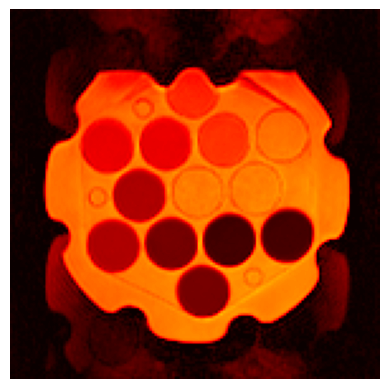

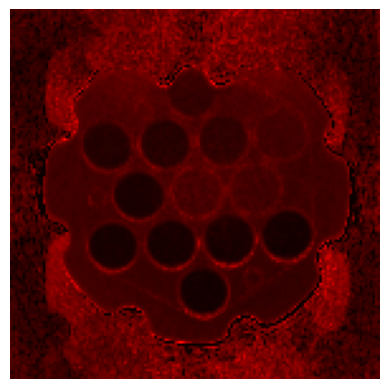

Median ADC (whole brain): 1.641
ML dADC (whole brain): 0.0950 and median dADC: 0.0926

--- Scan: trap_mmt0_Ncalib2 ---


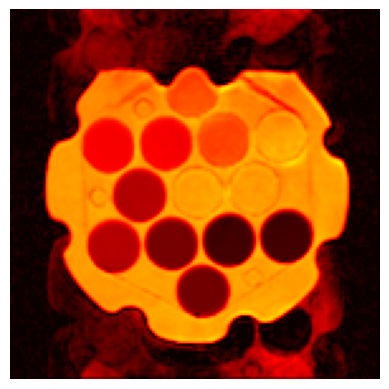

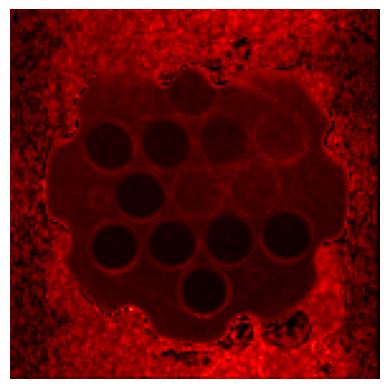

Median ADC (whole brain): 1.807
ML dADC (whole brain): 0.0750 and median dADC: 0.0781

--- Scan: gropt_mmt0_Ncalib2 ---


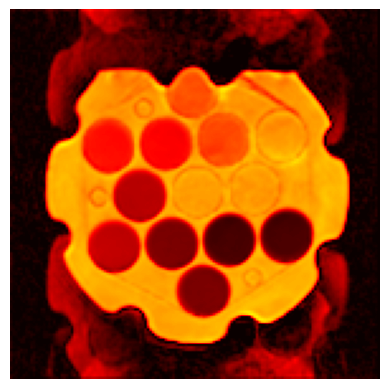

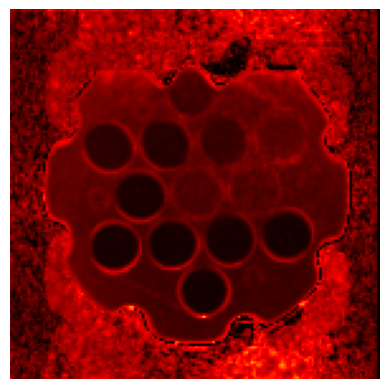

Median ADC (whole brain): 1.801
ML dADC (whole brain): 0.0950 and median dADC: 0.0993

--- Scan: trap_mmt1_Ncalib2 ---


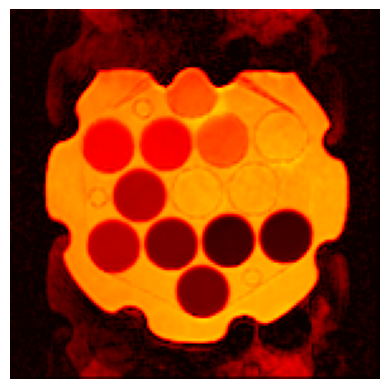

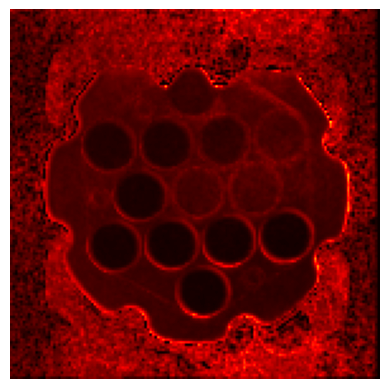

Median ADC (whole brain): 1.817
ML dADC (whole brain): 0.0850 and median dADC: 0.0871

--- Scan: gropt_mmt1_Ncalib2 ---


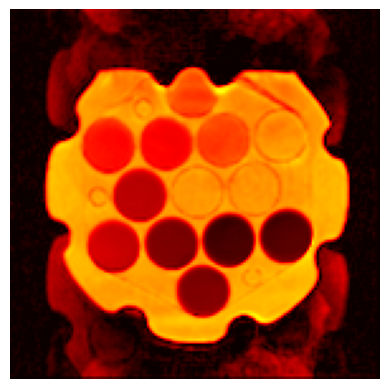

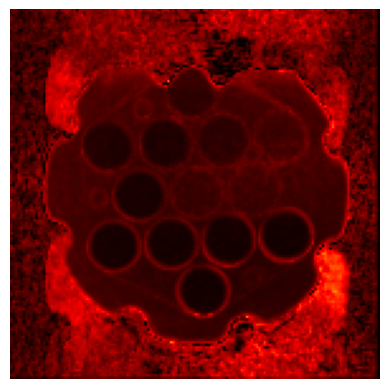

Median ADC (whole brain): 1.767
ML dADC (whole brain): 0.0750 and median dADC: 0.0723


In [14]:
# -------------------------------------------------------------------------
# Storage containers
# -------------------------------------------------------------------------
data_all_vols = {}
adc_all_vols = {}           # store ADC maps per scan
dadc_all_vols = {}          # store dADC maps per scan
mask_all_vols = {}          # stores selected mask per scan
maskbank_all_vols = {}      # stores all masks per volunteer
median_adc_all_vols = {}    # store median ADC in brain per scan
median_dADC_all_vols = {}   # store median dADC in brain per scan

# -------------------------------------------------------------------------
# Loop over volunteers
# -------------------------------------------------------------------------
for volunteer in volunteers:
    print(f"\n============================")
    print(f"Processing volunteer: {volunteer}")
    print(f"============================")

    data_all_vols[volunteer] = []
    adc_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []
    adc_all_vols[volunteer] = []
    dadc_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []
    median_dADC_all_vols[volunteer] = []

    # Dictionary to store all masks
    maskbank_all_vols[volunteer] = {}

    # ---------------------------------------------------------
    # 🔍 Load all masks for this volunteer
    # ---------------------------------------------------------
    volpath = os.path.join(main_path, volunteer)
    mask_files = [
        f for f in os.listdir(volpath)
        if f.endswith(".nrrd") and not f.startswith("._")
    ]

    print(f"Found {len(mask_files)} masks:")
    for mf in mask_files:
        print(f"   - {mf}")

    # if in vivo only load brain mask 
    
    for mf in mask_files:
        mpath = os.path.join(volpath, mf)
        mask_arr = nrrd.read(mpath)[0].astype('float32')
        if volunteer == 'Phantom_01B':
            mask_arr = np.flip(mask_arr, axis = 1)
        mask_arr[mask_arr == 0] = np.nan
        mask_arr = np.flip(mask_arr, axis=(0))
        mask_name_clean = os.path.splitext(mf)[0]
        maskbank_all_vols[volunteer][mask_name_clean] = mask_arr

        
    median_adc_all_vols[volunteer] = []
    median_dADC_all_vols[volunteer] = []

    # ---------------------------------------------------------
    # Loop over scans
    # ---------------------------------------------------------
    count = 0
    for folder in data_folders:
        print(f"\n--- Scan: {folder} ---")
        base_path = os.path.join(main_path, volunteer, folder)
        uncertainty_path = os.path.join(bootstrappoing_path, volunteer, folder)

        NifTi_path = os.path.join(base_path, process_folder, process_file + '.nii')
        b_values_path = os.path.join(base_path, process_folder, process_file + '.bvals')
        b_vectors_path = os.path.join(base_path, process_folder, process_file + '.bvecs')
        header_path = os.path.join(base_path, process_folder, process_file + '.header')
        adc_path = os.path.join(base_path, adc_folder, 'Standard_DWI_Metrics.mat')
        dADC_path = os.path.join(uncertainty_path,  'Invariant_Uncertainties.mat')

        # Skip if missing
        if not all(os.path.exists(p) for p in [NifTi_path, b_values_path, b_vectors_path, adc_path]):
            print(f"⚠️ Missing files for {folder}. Skipping.")
            continue

        # ---------------------------------------------------------
        # Load DWI
        # ---------------------------------------------------------
        [mat_stack, bvals_stack, bvecs_stack,
         Header, voxel_resolution, affine_matrix] = NifTi_Reader(
            NifTi_path, b_values_path, b_vectors_path, header_path, info='OFF'
        )

        tmp_norm, _, _ = normalize_complex_image(mat_stack, target_value=1000)
        tmp_bg_phs = np.real(bg_phs_removal(tmp_norm))
        [mat_sorted, bvals_sorted, bvecs_sorted] = stacked2sorted(
            tmp_bg_phs, bvals_stack, bvecs_stack
        )

        # Slice ordering correction
        if count == 0:
            Ns = mat_sorted.shape[2]
            odd = np.arange(0, Ns, 2)
            even = np.arange(1, Ns, 2)
            interleaved = np.concatenate([even, odd])
            inv_order = np.argsort(interleaved)
            mat_sorted = mat_sorted[:, :, inv_order, :, :]

        # Flip
        mat_sorted = np.flip(mat_sorted, axis=0)

        # ---------------------------------------------------------
        # Load ADC
        # ---------------------------------------------------------
        Standard_DWI_Metrics = scipy.io.loadmat(adc_path)
        adc_map = Standard_DWI_Metrics['ADC']  # shape: (X, Y, Z)
        adc_all_vols[volunteer].append(adc_map)
        plt.imshow(adc_map,vmin = 0, vmax = 3, cmap = 'hot')
        plt.axis('off')
        plt.show()

        # ---------------------------------------------------------
        # Load dADC
        # ---------------------------------------------------------
        Invariant_Uncertainties = scipy.io.loadmat(dADC_path)
        dADC_map = Invariant_Uncertainties['dADC']  # shape: (X, Y, Z)
        dadc_all_vols[volunteer].append(dADC_map)
        plt.imshow(dADC_map,vmin = 0, vmax = 1, cmap = 'hot')
        plt.axis('off')
        plt.show()


        # ---------------------------------------------------------
        # Median ADC in whole-brain mask (per volunteer, per scan)
        # ---------------------------------------------------------
        brain_mask = maskbank_all_vols[volunteer]['mask1']  # adjust key if needed

        adc_masked = adc_map * brain_mask
        adc_masked[adc_masked > 3] = np.nan
        adc_clean = adc_masked[np.isfinite(adc_masked) & (adc_masked > 0)]

        if adc_clean.size == 0:
            median_adc = np.nan
        else:
            median_adc = np.nanmedian(adc_clean)

        median_adc_all_vols[volunteer].append(median_adc)

        print(f"Median ADC (whole brain): {median_adc:.3f}")

        # ---------------------------------------------------------
        # Maximum-likelihood dADC in whole-brain mask (per volunteer, per scan)
        # ---------------------------------------------------------
        dADC_masked = dADC_map * brain_mask
        dADC_clean = dADC_masked[np.isfinite(dADC_masked) & (dADC_masked > 0)]

        if dADC_clean.size == 0:
            ml_dADC = np.nan
        else:
            # Histogram-based maximum likelihood (mode)
            num_bins = np.linspace(0, 4, 401)   # adjust range if needed for dADC
            vals, bin_edges = np.histogram(
                dADC_clean,
                bins=num_bins,
                range=(0, 4),
                density=True
            )

            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

            # Normalize to percentage (same as your MD code)
            h = (vals / np.sum(vals)) * 100

            ml_dADC = bin_centers[np.argmax(h)]

        print(f"ML dADC (whole brain): {ml_dADC:.4f} and median dADC: {np.nanmedian(dADC_clean):.4f}")
        median_dADC_all_vols[volunteer].append(ml_dADC)

        # ---------------------------------------------------------
        # Store DWI + selected mask
        # ---------------------------------------------------------
        tmp_brain_mask = brain_mask[...,np.newaxis,np.newaxis]
        tmp_brain_mask[np.isnan(tmp_brain_mask)] = 0
        # if volunteer name does not contain phantom
        if 'phantom' not in volunteer.lower():
            data_all_vols[volunteer].append(mat_sorted * tmp_brain_mask)
        else:
            data_all_vols[volunteer].append(mat_sorted)
        mask_to_use = maskbank_all_vols[volunteer][mask_name]  # selected mask
        mask_all_vols[volunteer].append(mask_to_use)

        count += 1


=== Plotting volunteer: Phantom_DWI ===


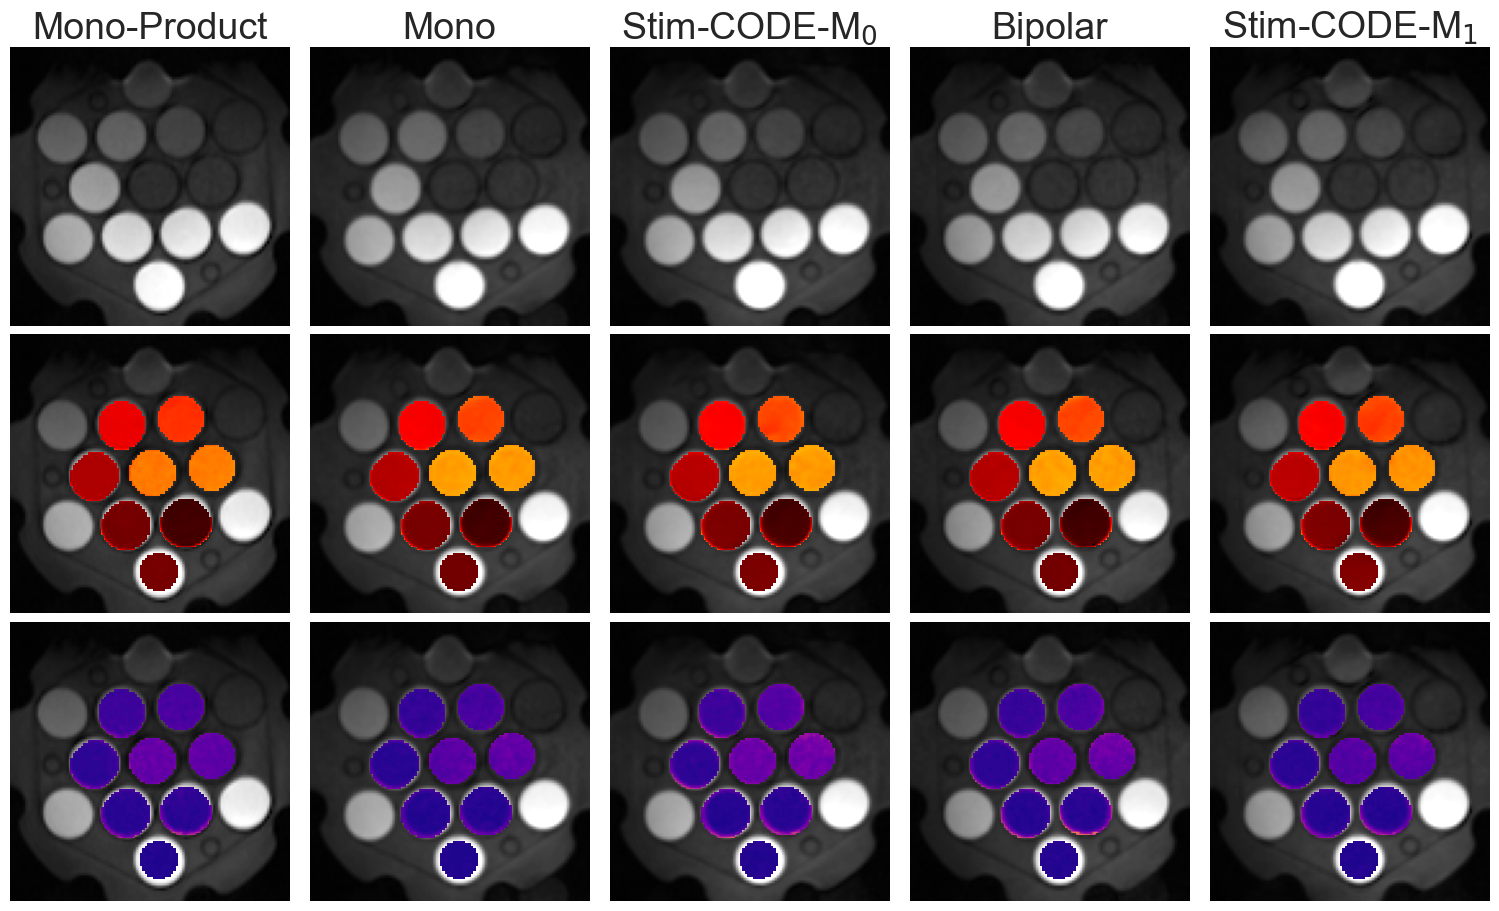

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ------------------------
# Global style
# ------------------------
mpl.rcParams['axes.labelweight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'

rocket_cmap = sns.color_palette("rocket", as_cmap=True)

# ------------------------
# Helper: center crop
# ------------------------
def crop_center(img, crop_x_frac=0.9, crop_y_frac=0.9):
    """
    Center-crop an image by fractional size.
    crop_x_frac, crop_y_frac in (0, 1]; e.g. 0.9 = crop 5% per side
    """
    nx, ny = img.shape[:2]
    cx = int(nx * crop_x_frac)
    cy = int(ny * crop_y_frac)

    x0 = (nx - cx) // 2
    y0 = (ny - cy) // 2

    return img[x0:x0 + cx, y0:y0 + cy]

# ------------------------
# Settings
# ------------------------
plot_slices = {
    'V001': 0, 'V002': 0, 'V003': 0, 'V004': 0, 'V005': 0,
    'V006': 0, 'V007': 0, 'V008': 0, 'V009': 0, 'V010': 0,
    'Phantom': 0, 'Phantom_01B': 0, 'Phantom_01A': 0, 'Phantom_DWI': 0,
    'Phantom_Sphere': 0, 'Phantom_DWI_New': 0, 'Phantom_New': 0,
}

scans_to_plot = data_folders
diff_dir = 1

# Crop amount (adjust here)
crop_x_frac = 0.75
crop_y_frac = 0.75

# Font sizes
title_fs = 27
ylabel_fs = 28
tick_fs = 18

# Color scale limits
dwi_vmin, dwi_vmax = 0, 800
adc_vmin, adc_vmax = 0, 3
dADC_vmin, dADC_vmax = 0, 0.5

# Column labels
col_labels = [
    'Mono-Product',
    'Mono', 'Stim-CODE-M$_0$',
    'Bipolar', 'Stim-CODE-M$_1$'
]

# ------------------------
# Loop over volunteers
# ------------------------
for volunteer in volunteers:
    print(f"\n=== Plotting volunteer: {volunteer} ===")

    slice_idx = plot_slices[volunteer]
    n_rows = 3   # DWI / ADC / dADC
    n_cols = len(scans_to_plot)

    fig, axs = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 9),
        constrained_layout=True
    )

    if n_cols == 1:
        axs = axs[:, np.newaxis]

    # Row labels
    axs[0, 0].set_ylabel('DWI', fontsize=ylabel_fs)
    axs[1, 0].set_ylabel('ADC', fontsize=ylabel_fs)
    axs[2, 0].set_ylabel('dADC', fontsize=ylabel_fs)

    # ------------------------
    # Loop over scans (columns)
    # ------------------------
    for col_idx, folder in enumerate(scans_to_plot):

        try:
            idx_folder = data_folders.index(folder)
        except ValueError:
            print(f"⚠️ Folder {folder} not found for {volunteer}, skipping")
            continue

        data = data_all_vols[volunteer][idx_folder]

        # ------------------------
        # Row 0: DWI
        # ------------------------
        if col_labels[col_idx] == 'Mono-Product':
            dwi_img = np.nanmean(np.real(data), axis=-1)[:, :, slice_idx, diff_dir]
        else:
            dwi_img = np.nanmean(np.real(data), axis=-1)[:, :, slice_idx, diff_dir]

        dwi_img = crop_center(dwi_img, crop_x_frac, crop_y_frac)

        axs[0, col_idx].imshow(
            dwi_img, cmap='gray',
            vmin=dwi_vmin, vmax=dwi_vmax
        )
        axs[0, col_idx].set_title(col_labels[col_idx], fontsize=title_fs)
        axs[0, col_idx].axis('off')

        # ------------------------
        # Row 1: ADC + masks
        # ------------------------
        adc_img = adc_all_vols[volunteer][idx_folder][:, :, slice_idx]
        adc_img = crop_center(adc_img, crop_x_frac, crop_y_frac)

        axs[1, col_idx].imshow(
            dwi_img, cmap='gray',
            vmin=dwi_vmin, vmax=dwi_vmax
        )

        for mask_name, mask_arr in maskbank_all_vols[volunteer].items():
            mask_slice = mask_arr[:, :, slice_idx]
            mask_slice = crop_center(mask_slice, crop_x_frac, crop_y_frac)
            mask_slice = mask_slice.astype(float)
            mask_slice[mask_slice == 0] = np.nan

            adc_masked = adc_img * mask_slice

            axs[1, col_idx].imshow(
                adc_masked,
                cmap='hot',
                alpha=1,
                vmin=adc_vmin,
                vmax=adc_vmax
            )

        axs[1, col_idx].axis('off')

        # ------------------------
        # Row 2: dADC + masks
        # ------------------------
        dADC_img = dadc_all_vols[volunteer][idx_folder][:, :, slice_idx]
        dADC_img = crop_center(dADC_img, crop_x_frac, crop_y_frac)

        axs[2, col_idx].imshow(
            dwi_img, cmap='gray',
            vmin=dwi_vmin, vmax=dwi_vmax
        )

        for mask_name, mask_arr in maskbank_all_vols[volunteer].items():
            mask_slice = mask_arr[:, :, slice_idx]
            mask_slice = crop_center(mask_slice, crop_x_frac, crop_y_frac)
            mask_slice = mask_slice.astype(float)
            mask_slice[mask_slice == 0] = np.nan

            dADC_masked = dADC_img * mask_slice

            axs[2, col_idx].imshow(
                dADC_masked,
                cmap=sns.color_palette("plasma", as_cmap=True),
                alpha=1,
                vmin=dADC_vmin,
                vmax=dADC_vmax
            )

        axs[2, col_idx].axis('off')

    plt.show()

    fig.savefig(
        f'Fig_ADC_dADC_Overlays_{volunteer}.svg',
        dpi=300,
        bbox_inches='tight'
    )

[ADC ] Mono                  0.718  [ 0.580,  0.762]
[ADC ] Stim-CODE-M$_0$       0.727  [ 0.634,  0.750]
[ADC ] Bipolar               0.741  [ 0.690,  0.804]
[ADC ] Stim-CODE-M$_1$       0.757  [ 0.637,  0.788]


IndexError: list index out of range

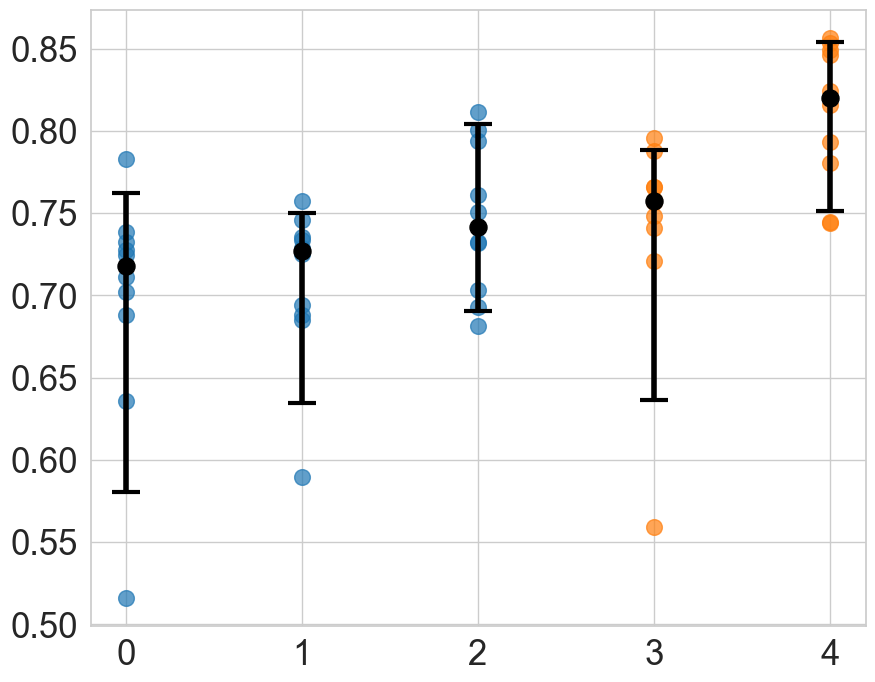

In [ ]:
# ============================================================
# Scatter + point plot of median ADC AND dADC per scan
# with bootstrapped 95% CI
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 128
MEDIAN_SIZE    = 150
CI_LINEWIDTH   = 4
CI_CAPSIZE     = 10
CI_CAPTHICK    = 3

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ------------------------------------------------------------
# Palette + labels
# ------------------------------------------------------------
palette = ['#1f77b4']*3 + ['#ff7f0e']*2

col_labels = [
    #'Mono-Siemens',
    'Mono',
    'Stim-CODE-M$_0$',
    'Bipolar',
    'Stim-CODE-M$_1$',
]

# ------------------------------------------------------------
# Bootstrap CI
# ------------------------------------------------------------
# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000
    
    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lower_bound = np.percentile(bs, 2.5, axis = 0).mean()
    upper_bound = np.percentile(bs, 97.5, axis = 0).mean()
    CI_low  = lower_bound
    CI_high = upper_bound
    return [np.nanmedian(data),CI_low, CI_high]

# ------------------------------------------------------------
# Reformat data: scan → list of volunteer values
# ------------------------------------------------------------
scan_adc  = {scan: [] for scan in data_folders}
scan_dADC = {scan: [] for scan in data_folders}

for volunteer in median_adc_all_vols:
    for i, scan in enumerate(data_folders):
        if i < len(median_adc_all_vols[volunteer]):
            scan_adc[scan].append(median_adc_all_vols[volunteer][i])
        if i < len(median_dADC_all_vols[volunteer]):
            scan_dADC[scan].append(median_dADC_all_vols[volunteer][i])

# ------------------------------------------------------------
# Plot (two stacked panels)
# ------------------------------------------------------------
fig, ax = plt.subplots(
    1, 1,
    figsize=(10, 8),
    sharex=True
)

xpos = np.arange(len(data_folders))
jitter = 0.0

# ============================================================
# TOP PANEL — ADC
# ============================================================

for i, scan in enumerate(data_folders):
    y = np.asarray(scan_adc[scan], dtype=float)
    y = y[np.isfinite(y)]

    ax.scatter(
        np.full_like(y, xpos[i]) + np.random.uniform(-jitter, jitter, size=len(y)),
        y,
        s=SCATTER_SIZE,
        alpha=0.7,
        color=palette[i]
    )

    median_val, lo, hi = bootstrap_ci(y)

    ax.errorbar(
        xpos[i],
        median_val,
        yerr=[[median_val - lo], [hi - median_val]],
        fmt='o',
        markersize=np.sqrt(MEDIAN_SIZE),
        lw=CI_LINEWIDTH,
        capsize=CI_CAPSIZE,
        capthick=CI_CAPTHICK,
        color='black',
        zorder=10
    )

    print(f"[ADC ] {col_labels[i]:<20s} {median_val:6.3f}  [{lo:6.3f}, {hi:6.3f}]")

ax.set_ylabel('×10$^{-3}$ mm$^2$/s')
ax.set_ylim([0, 1.1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================
# BOTTOM PANEL — dADC
# ============================================================

for i, scan in enumerate(data_folders):
    y = np.asarray(scan_dADC[scan], dtype=float)
    y = y[np.isfinite(y)]

    ax.scatter(
        np.full_like(y, xpos[i]) + np.random.uniform(-jitter, jitter, size=len(y)),
        y,
        s=SCATTER_SIZE,
        alpha=0.7,
        color=palette[i]
    )

    median_val, lo, hi = bootstrap_ci(y)

    ax.errorbar(
        xpos[i],
        median_val,
        yerr=[[median_val - lo], [hi - median_val]],
        fmt='o',
        markersize=np.sqrt(MEDIAN_SIZE),
        lw=CI_LINEWIDTH,
        capsize=CI_CAPSIZE,
        capthick=CI_CAPTHICK,
        color='black',
        zorder=10   )

    print(f"[dADC] {col_labels[i]:<20s} {median_val:6.3f}  [{lo:6.3f}, {hi:6.3f}]")

#ax.set_ylabel('dADC')
#ax.set_ylim([0, 1.0])
# set yticks to be 0, 0.25, 0.5, 0.75, 1.0
yticks = np.arange(0, 1.25, 0.25)
ax.set_yticks(yticks)

ax.set_xticks(xpos)
ax.set_xticklabels(col_labels, rotation=30, ha='right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import numpy as np
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import AnovaRM
import pandas as pd

def repeated_measures_stats(scan_data, label, data_folders, alpha_global=0.05):
    """
    Compute repeated-measures statistics for ADC/dADC per scan across subjects.

    Parameters
    ----------
    scan_data : dict
        Keys are scan names, values are lists of subject values.
    label : str
        Name of the metric (e.g., 'ADC', 'dADC') for printing.
    data_folders : list of str
        Ordered list of scan names.
    alpha_global : float
        Threshold for global test significance to compute post-hoc.

    Returns
    -------
    pairs : list of tuples
        Scan index pairs for post-hoc comparisons.
    pvals_corr : list of floats
        Holm-corrected post-hoc p-values (NaN if global test not significant).
    """

    # --------------------------
    # Build subject × condition matrix
    # --------------------------
    X = np.array([[scan_data[scan][i] for scan in data_folders]
                  for i in range(len(scan_data[data_folders[0]]))], dtype=float)

    # Remove subjects with missing values
    X = X[np.all(np.isfinite(X), axis=1)]
    n_subjects, n_conditions = X.shape

    print(f"\n================ {label} =================")
    print(f"Subjects used: {n_subjects}")

    # --------------------------
    # Test residual normality
    # --------------------------
    residuals = X - X.mean(axis=1, keepdims=True)
    W, p_norm = shapiro(residuals.ravel())
    print(f"Shapiro–Wilk residuals: W={W:.3f}, p={p_norm:.4g}")

    pairs = list(combinations(range(n_conditions), 2))
    pvals = []

    # --------------------------
    # Parametric: repeated-measures ANOVA
    # --------------------------
    if p_norm > 0.05:
        print("Residuals normal → repeated-measures ANOVA")

        # Convert to long-form DataFrame for AnovaRM
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(n_subjects), n_conditions),
            'scan': np.tile(data_folders, n_subjects),
            'value': X.ravel()
        })

        # Run repeated-measures ANOVA
        aov = AnovaRM(df, depvar='value', subject='subject', within=['scan']).fit()
        print(aov)
        p_global = aov.anova_table['Pr > F'][0]
        print(f"Global ANOVA p = {p_global:.4g}")
        test_name = "Repeated-measures ANOVA"

        # Only compute post-hoc if global significant
        if p_global < alpha_global:
            for i, j in pairs:
                _, p = ttest_rel(X[:, i], X[:, j])
                pvals.append(p)
        else:
            print("Global test not significant → skipping post-hoc")
            pvals = [np.nan] * len(pairs)

    # --------------------------
    # Non-parametric: Friedman test
    # --------------------------
    else:
        print("Residuals non-normal → Friedman test")
        stat, p_global = friedmanchisquare(*X.T)
        kendalls_w = stat / (n_subjects * (n_conditions - 1))
        print(f"Friedman χ²({n_conditions-1}) = {stat:.3f}, p={p_global:.4g}, Kendall's W={kendalls_w:.3f}")
        test_name = "Friedman test"

        if p_global < alpha_global:
            for i, j in pairs:
                _, p = wilcoxon(X[:, i], X[:, j])
                pvals.append(p)
        else:
            print("Global test not significant → skipping post-hoc")
            pvals = [np.nan] * len(pairs)

    # --------------------------
    # Holm–Bonferroni correction
    # --------------------------
    if any(np.isfinite(pvals)):
        _, pvals_corr, _, _ = multipletests(pvals, method='holm-sidak')
    else:
        pvals_corr = [np.nan] * len(pairs)

    # --------------------------
    # Print pairwise results
    # --------------------------
    print(f"\nPairwise comparisons ({label}, {test_name}, holm-sidak):")
    for (i, j), p in zip(pairs, pvals_corr):
        signif = "✓" if p < 0.05 else "ns"
        print(f"{data_folders[i]} vs {data_folders[j]}: p_corr = {p:.4g} ({signif})")

    return pairs, pvals_corr
# ============================================================
# Run stats for ADC
# ============================================================
pairs_adc, pvals_adc_corr = repeated_measures_stats(scan_adc, 'ADC', data_folders)


# ============================================================
# Run stats for dADC
# ============================================================
pairs_dadc, pvals_dadc_corr = repeated_measures_stats(scan_dADC, 'dADC', data_folders)


================ ADC =================
Subjects used: 10
Shapiro–Wilk residuals: W=0.978, p=0.6241
Residuals normal → repeated-measures ANOVA
              Anova
     F Value Num DF  Den DF Pr > F
----------------------------------
scan 20.3504 3.0000 27.0000 0.0000

Global ANOVA p = 4.225e-07

Pairwise comparisons (ADC, Repeated-measures ANOVA, Holm-corrected):
trap_mmt0_Ncalib2 vs gropt_mmt0_Ncalib2: p_corr = 0.08075 (ns)
trap_mmt0_Ncalib2 vs trap_mmt1_Ncalib2: p_corr = 0.08075 (ns)
trap_mmt0_Ncalib2 vs gropt_mmt1_Ncalib2: p_corr = 6.07e-05 (✓)
gropt_mmt0_Ncalib2 vs trap_mmt1_Ncalib2: p_corr = 0.7236 (ns)
gropt_mmt0_Ncalib2 vs gropt_mmt1_Ncalib2: p_corr = 6.62e-05 (✓)
trap_mmt1_Ncalib2 vs gropt_mmt1_Ncalib2: p_corr = 0.007657 (✓)

================ dADC =================
Subjects used: 10
Shapiro–Wilk residuals: W=0.935, p=0.02442
Residuals non-normal → Friedman test
Friedman χ²(3) = 25.100, p=1.471e-05, Kendall's W=0.837

Pairwise comparisons (dADC, Friedman test, Holm-corrected):
t

/opt/anaconda3/envs/CarDpy3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/opt/anaconda3/envs/CarDpy3/lib/python3.8/site-packages/scipy/stats/_morestats.py:3269: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


: 

[ADC] Mono-Siemens         0.72  [[0.14], [0.04]]
[ADC] Mono                 0.73  [[0.09], [0.02]]
[ADC] Stim-CODE-M$_0$      0.74  [[0.05], [0.06]]
[ADC] Bipolar              0.76  [[0.12], [0.03]]
[ADC] Stim-CODE-M$_1$      0.82  [[0.07], [0.03]]
[dADC] Mono-Siemens         0.08  [[0.01], [0.01]]
[dADC] Mono                 0.08  [[0.00], [0.02]]
[dADC] Stim-CODE-M$_0$      0.08  [[0.00], [0.01]]
[dADC] Bipolar              0.11  [[0.01], [0.01]]
[dADC] Stim-CODE-M$_1$      0.10  [[0.01], [0.01]]


NameError: name 'pvals_adc_corr' is not defined

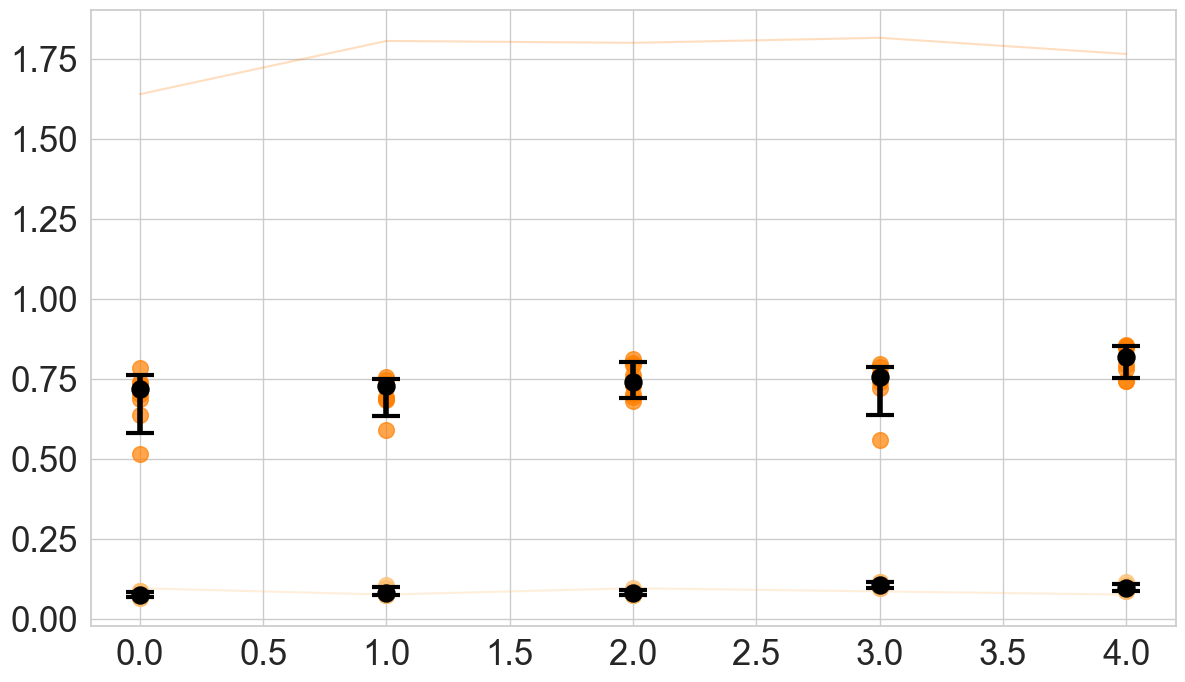

In [24]:
# ============================================================
# Scatter + point plot of median ADC AND dADC per scan
# with bootstrapped 95% CI + volunteer lines + significance
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import transforms as mtransforms

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 128
MEDIAN_SIZE    = 150
CI_LINEWIDTH   = 4
CI_CAPSIZE     = 10
CI_CAPTHICK    = 3

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ------------------------------------------------------------
# Palette + labels
# ------------------------------------------------------------
# Dark green for ADC, light green for dADC
palette_adc  = [sns.color_palette('Paired', 10)[7]] * len(data_folders)
palette_dadc = [sns.color_palette('Paired', 10)[6]] * len(data_folders)


col_labels = [
    'Mono-Siemens',
    'Mono',
    'Stim-CODE-M$_0$',
    'Bipolar',
    'Stim-CODE-M$_1$',
]

# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000
    
    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lower_bound = np.percentile(bs, 2.5, axis = 0).mean()
    upper_bound = np.percentile(bs, 97.5, axis = 0).mean()
    CI_low  = lower_bound
    CI_high = upper_bound
    return [np.nanmedian(data),CI_low, CI_high]

# ------------------------------------------------------------
# Significance helpers
# ------------------------------------------------------------
def p_to_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return None

def add_sig_bracket(ax, x1, x2, y, text, h=0.02, lw=2, text_offset_pts=-38.):
    # Draw bracket in data coordinates
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=lw, color='black', clip_on=False
    )

    # Transform: data coords + fixed point offset for text
    trans = ax.transData + mtransforms.ScaledTranslation(
        0, text_offset_pts / 202, ax.figure.dpi_scale_trans
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha='center',
        va='bottom',
        transform=trans,
        fontsize=TICK_FONTSIZE
    )
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
xpos = np.arange(len(data_folders))
jitter = 0.0


# ---------- Volunteer lines: ADC ----------
for vol in median_adc_all_vols:
    y = np.array([median_adc_all_vols[vol][i] if i < len(median_adc_all_vols[vol]) else np.nan 
                  for i in range(len(data_folders))])
    ax.plot(xpos, y, color=palette_adc[0], alpha=0.25, lw=1.5)

# ---------- Scatter + CI: ADC ----------
adc_tops = []
for i, scan in enumerate(data_folders):
    y = np.asarray(scan_adc[scan], float)
    y = y[np.isfinite(y)]
    ax.scatter(xpos[i]+np.random.uniform(-jitter,jitter,len(y)), y, s=SCATTER_SIZE, color=palette_adc[i], alpha=0.7)
    med, lo, hi = bootstrap_ci(y)
    adc_tops.append(hi)
    ax.errorbar(xpos[i], med, yerr=[[med-lo],[hi-med]], fmt='o', markersize=np.sqrt(MEDIAN_SIZE),
                lw=CI_LINEWIDTH, capsize=CI_CAPSIZE, capthick=CI_CAPTHICK, color='black', zorder=10)
    
    print(
    f"[ADC] {col_labels[i]:<20s} "
    f"{med:.2f}  [[{med-lo:.2f}], [{hi-med:.2f}]]"
        )
# ---------- Volunteer lines: dADC ----------
for vol in median_dADC_all_vols:
    y = np.array([median_dADC_all_vols[vol][i] if i < len(median_dADC_all_vols[vol]) else np.nan 
                  for i in range(len(data_folders))])
    ax.plot(xpos, y, color=palette_dadc[0], alpha=0.25, lw=1.5)

# ---------- Scatter + CI: dADC ----------
dadc_tops = []
for i, scan in enumerate(data_folders):
    y = np.asarray(scan_dADC[scan], float)
    y = y[np.isfinite(y)]
    ax.scatter(xpos[i]+np.random.uniform(-jitter,jitter,len(y)), y, s=SCATTER_SIZE, color=palette_dadc[i], alpha=0.7)
    med, lo, hi = bootstrap_ci(y)
    dadc_tops.append(hi)
    ax.errorbar(xpos[i], med, yerr=[[med-lo],[hi-med]], fmt='o', markersize=np.sqrt(MEDIAN_SIZE),
                lw=CI_LINEWIDTH, capsize=CI_CAPSIZE, capthick=CI_CAPTHICK, color='black', zorder=10)
    
    print(
    f"[dADC] {col_labels[i]:<20s} "
    f"{med:.2f}  [[{med-lo:.2f}], [{hi-med:.2f}]]"
        )

# ---------- Significance brackets: ADC ----------
y0 = max(adc_tops) + 0.05   # starting point above the highest ADC CI
n_brackets_adc = sum(p < 0.05 for p in pvals_adc_corr)  # count significant brackets
if n_brackets_adc > 0:
    spacing_adc = 0.055  # total spacing per bracket
    current_idx = 0
    for ((i, j), p) in zip(pairs_adc, pvals_adc_corr):
        star = p_to_star(p)
        if star:
            y = y0 + current_idx * spacing_adc
            add_sig_bracket(ax, i, j, y, star)
            current_idx += 1


# ---------- Significance brackets: dADC ----------
y0 = max(dadc_tops) + 0.05  # starting point above the highest dADC CI
n_brackets_dadc = sum(p < 0.05 for p in pvals_dadc_corr)  # count significant brackets
if n_brackets_dadc > 0:
    spacing_dadc = 0.055  # vertical spacing per bracket
    current_idx = 0
    for ((i, j), p) in zip(pairs_dadc, pvals_dadc_corr):
        star = p_to_star(p)
        if star:
            y = y0 + current_idx * spacing_dadc
            add_sig_bracket(ax, i, j, y, star)
            current_idx += 1

# ---------- Formatting ----------
ax.set_xticks(xpos)
ax.set_xticklabels(col_labels, rotation=30, ha='right')
ax.set_ylabel('×10$^{-3}$ mm$^2$/s')
ax.set_ylim(0, max(max(adc_tops), max(dadc_tops)) + 0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
fig.savefig(
    'Fig_ADC_dADC_Scatter_with_Significance.svg',
    dpi=300,
    bbox_inches='tight'
)

: 

: 

: 

: 

: 

: 

: 

: 

: 

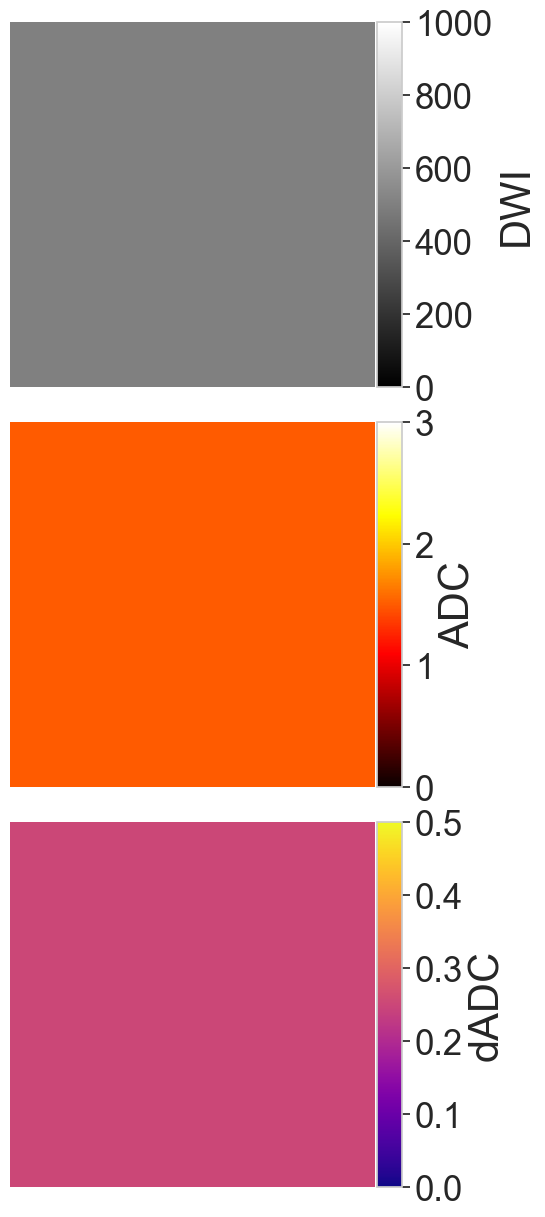

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------
# Dummy images for colorbars
# ------------------------
dwi_img_dummy = np.ones((1, 1)) * (dwi_vmin + dwi_vmax) / 2
adc_img_dummy = np.ones((1, 1)) * (adc_vmin + adc_vmax) / 2
dADC_img_dummy = np.ones((1, 1)) * (dADC_vmin + dADC_vmax) / 2

# ------------------------
# Stack into one figure
# ------------------------
fig, axs = plt.subplots(3, 1, figsize=(4, 12), constrained_layout=True)

# Control thickness and padding
cbar_width = 0.25  # fraction of axis width
cbar_pad   = 0.02

# Tick font size
cbar_tick_fs = 25

# Row 0: DWI
im0 = axs[0].imshow(dwi_img_dummy, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
axs[0].axis('off')
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size=cbar_width, pad=cbar_pad)
cb0 = fig.colorbar(im0, cax=cax0, label='DWI')
cb0.ax.tick_params(labelsize=cbar_tick_fs)

# Row 1: ADC
im1 = axs[1].imshow(adc_img_dummy, cmap='hot', vmin=adc_vmin, vmax=adc_vmax)
axs[1].axis('off')
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size=cbar_width, pad=cbar_pad)
cb1 = fig.colorbar(im1, cax=cax1, label='ADC')
cb1.ax.tick_params(labelsize=cbar_tick_fs)

# Row 2: dADC
im2 = axs[2].imshow(dADC_img_dummy, cmap=sns.color_palette("plasma", as_cmap=True),
                     vmin=dADC_vmin, vmax=dADC_vmax)
axs[2].axis('off')
divider2 = make_axes_locatable(axs[2])
cax2 = divider2.append_axes("right", size=cbar_width, pad=cbar_pad)
cb2 = fig.colorbar(im2, cax=cax2, label='dADC')
cb2.ax.tick_params(labelsize=cbar_tick_fs)

plt.show()
fig.savefig('stacked_colorbars_thick_ticks.svg', dpi=300, bbox_inches='tight')

: 